In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import random
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import r2_score,mean_absolute_error, mean_squared_error
from transformers import RobertaTokenizer, RobertaModel
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
from collections import Counter
from imblearn.over_sampling import RandomOverSampler
from torch.utils.data import DataLoader, Subset
from scipy.stats import pearsonr
from tqdm import tqdm
from sklearn.exceptions import FitFailedWarning
import warnings
from sklearn.model_selection import ParameterSampler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.model_selection import RandomizedSearchCV
import matplotlib.pyplot as plt
from scipy.stats import norm
import matplotlib
from sklearn.base import clone


In [2]:
import torch

# 检查是否有可用的 GPU
if torch.cuda.is_available():
    print("CUDA 可用，GPU 可用。")
    print(f"CUDA 版本: {torch.version.cuda}")
    print(f"GPU 数量: {torch.cuda.device_count()}")
    print(f"当前设备名称: {torch.cuda.get_device_name(0)}")
    print(f"当前设备总内存: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")
else:
    print("CUDA 不可用，仅支持 CPU。")


CUDA 可用，GPU 可用。
CUDA 版本: 12.1
GPU 数量: 1
当前设备名称: NVIDIA GeForce RTX 4090 D
当前设备总内存: 23.64 GB


In [3]:
data=pd.read_excel("./fish_EC10.xlsx")
data=data.dropna()
smiles_data = data['SMILES_Canonical_RDKit'].tolist()
mgperL = data['mgperL'].values
Duration_Value= data['Duration_Value'].values

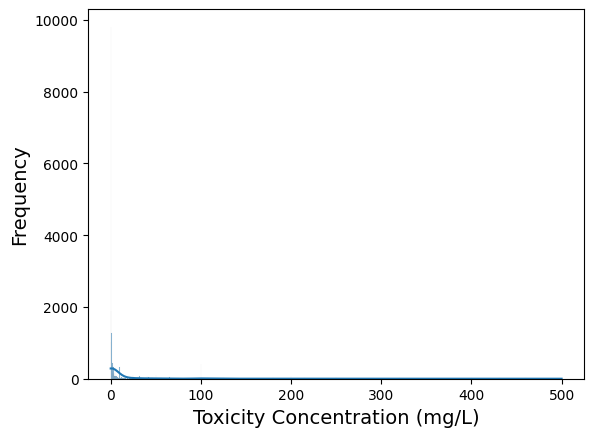

In [4]:
# 假设 mgperL 是毒性浓度数据的列表或数组
sns.histplot(mgperL, kde=True)
#plt.title('Original Toxicity Concentration Distribution')
plt.xlabel('Toxicity Concentration (mg/L)', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.show()

In [5]:
# 统计信息
mean = np.mean(mgperL)
median = np.median(mgperL)
std_dev = np.std(mgperL)
print(f"Mean: {mean}, Median: {median}, Std Dev: {std_dev}")


Mean: 16.99868165884863, Median: 0.4922, Std Dev: 53.78589674182999


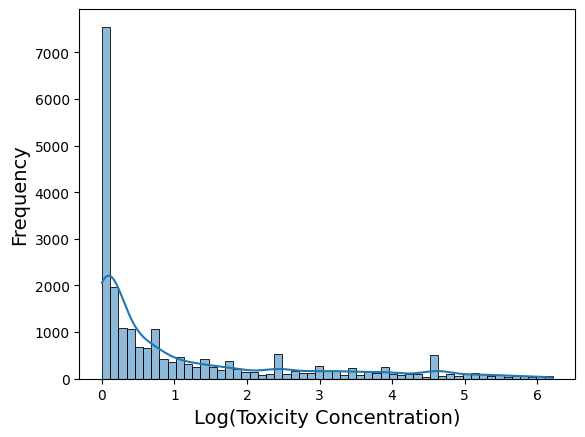

In [6]:
# 应用 log1p 变换并再次查看分布
log_mgperL = np.log1p(mgperL)
sns.histplot(log_mgperL, kde=True)
#plt.title('Log-transformed Toxicity Concentration Distribution')
plt.xlabel('Log(Toxicity Concentration)', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.show()

In [7]:
mgperL=np.log1p(mgperL)

In [8]:
# 数据增强函数：简单的 SMILES 序列翻转
def augment_smiles(smiles):
    """简单的数据增强方法，例如旋转 SMILES 字符串"""
    if random.random() > 0.5:
        return smiles[::-1]  # 翻转字符串
    return smiles

# 根据 mgperL 浓度生成分类标签
def generate_labels(mgperL):
    """根据 mgperL 的浓度范围生成分类标签"""
    if mgperL < 0.2:
        return 0  # high
    elif 0.2 <= mgperL < 1.5:
        return 1  # mid
    elif 1.5 <= mgperL < 3.5:
        return 2  # mid
    else:
        return 3  # low

# 数据集定义
class SMILES_Dataset(Dataset):
    def __init__(self, smiles, reg_labels, class_labels):
        self.smiles = smiles
        self.reg_labels = reg_labels  # 回归任务标签 (mgperL)
        self.class_labels = class_labels  # 分类任务标签

    def __len__(self):
        return len(self.smiles)

    def __getitem__(self, idx):
        #smiles = augment_smiles(self.smiles[idx])  # 数据增强
        smiles = self.smiles[idx]  # 数据增强
        reg_label = self.reg_labels[idx]
        class_label = self.class_labels[idx]
        tokens = tokenizer(smiles, padding='max_length', truncation=True, max_length=128, return_tensors="pt")
        return tokens, torch.tensor(reg_label, dtype=torch.float32), torch.tensor(class_label, dtype=torch.long)

# 多任务模型定义
class ChemBERTa_MultiTask(nn.Module):
    def __init__(self, num_classes):
        super(ChemBERTa_MultiTask, self).__init__()
        # 加载预训练的ChemBERTa模型
        self.chemberta = chemberta_model
        hidden_size = self.chemberta.config.hidden_size  # 一般为768
        # 回归任务的全连接层
        self.regressor = nn.Sequential(
            nn.Linear(hidden_size, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.3),
            nn.Linear(128, 1)
        )

        # 分类任务的全连接层
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.3),
            nn.Linear(128, 4)
        )

    def forward(self, tokens):
        output = self.chemberta(**tokens)
        cls_embedding = output.last_hidden_state[:, 0, :]  # [CLS] token 嵌入
        reg_output = self.regressor(cls_embedding)  # 回归任务输出
        class_output = self.classifier(cls_embedding)  # 分类任务输出
        return reg_output, class_output

In [10]:
# 加载 ChemBERTa 模型和 tokenizer
model_name = "../models/chemBERTa"
tokenizer = RobertaTokenizer.from_pretrained(model_name)
chemberta_model = RobertaModel.from_pretrained(model_name)

/root/miniconda3/lib/python3.10/site-packages/torch/_utils.py:831: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()


In [11]:
# 生成分类标签    
classification_labels = [generate_labels(mg) for mg in mgperL]

# 加载数据集
dataset = SMILES_Dataset(smiles_data, mgperL, classification_labels)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=32,drop_last=True)

In [12]:

# 如果 classification_labels 是列表，先将其转换为 Series
classification_labels_series = pd.Series(classification_labels)

# 计算各类别的数目
class_counts = classification_labels_series.value_counts()
class_counts

0    8900
1    7480
2    3398
3    2470
Name: count, dtype: int64

In [13]:
# 初始化多任务模型
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ChemBERTa_MultiTask(chemberta_model).to(device)

In [14]:



# 损失函数
reg_criterion = nn.L1Loss()  # 回归任务的损失
class_criterion = nn.CrossEntropyLoss()  # 分类任务的损失

# 优化器
optimizer = torch.optim.Adam(model.parameters(), lr=2e-5)

# 训练模型
num_epochs = 100
patience = 5
best_val_loss = float("inf")
early_stop_counter = 0



for epoch in range(num_epochs):
    model.train()
    running_reg_loss = 0.0
    running_class_loss = 0.0
    
    # 使用 tqdm 包装 train_loader
    train_loader_tqdm = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{num_epochs}] - Training")
    for tokens, reg_labels, class_labels in train_loader_tqdm:
        tokens = {key: val.squeeze(1).to(device) for key, val in tokens.items()}
        reg_labels = reg_labels.to(device)
        class_labels = class_labels.to(device)

        # 前向传播
        optimizer.zero_grad()
        reg_output, class_output = model(tokens)

        # 计算回归和分类任务的损失
        reg_loss = reg_criterion(reg_output.squeeze(), reg_labels)
        class_loss = class_criterion(class_output, class_labels)

        # 总损失
        loss = reg_loss + class_loss
        loss.backward()
        optimizer.step()

        running_reg_loss += reg_loss.item()
        running_class_loss += class_loss.item()
        
        # 在 tqdm 显示平均损失
        train_loader_tqdm.set_postfix({'Reg Loss': reg_loss.item(), 'Class Loss': class_loss.item()})

    avg_reg_loss = running_reg_loss / len(train_loader)
    avg_class_loss = running_class_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{num_epochs}], Train Reg Loss: {avg_reg_loss:.4f}, Train Class Loss: {avg_class_loss:.4f}")

    # 验证模型
    model.eval()
    val_reg_loss = 0.0
    val_class_loss = 0.0
    correct_class_preds = 0
    total_class_preds = 0
    all_preds = []
    all_labels = []
    
    val_loader_tqdm = tqdm(val_loader, desc=f"Epoch [{epoch+1}/{num_epochs}] - Validation")
    with torch.no_grad():
        for tokens, reg_labels, class_labels in val_loader_tqdm:
            tokens = {key: val.squeeze(1).to(device) for key, val in tokens.items()}
            reg_labels = reg_labels.to(device)
            class_labels = class_labels.to(device)

            # 前向传播
            reg_output, class_output = model(tokens)

            # 计算回归和分类任务的损失
            reg_loss = reg_criterion(reg_output.squeeze(), reg_labels)
            class_loss = class_criterion(class_output, class_labels)
            val_reg_loss += reg_loss.item()
            val_class_loss += class_loss.item()

            # 计算分类准确率
            _, predicted = torch.max(class_output, 1)
            correct_class_preds += (predicted == class_labels).sum().item()
            total_class_preds += class_labels.size(0)

            all_preds.extend(reg_output.squeeze().cpu().numpy())
            all_labels.extend(reg_labels.cpu().numpy())
            
            # 在 tqdm 显示平均损失
            val_loader_tqdm.set_postfix({'Reg Loss': reg_loss.item(), 'Class Loss': class_loss.item()})

    avg_val_reg_loss = val_reg_loss / len(val_loader)
    avg_val_class_loss = val_class_loss / len(val_loader)
    val_accuracy = correct_class_preds / total_class_preds
    val_r2 = r2_score(np.expm1(all_labels), np.expm1(all_preds))  # 还原 log1p 的值

    print(f"Val Reg Loss: {avg_val_reg_loss:.4f}, Val Class Loss: {avg_val_class_loss:.4f}, Val R²: {val_r2:.4f}, Val Accuracy: {val_accuracy:.4f}, Early Stop Counter: {early_stop_counter}")

    # 早停机制
    if avg_val_reg_loss < best_val_loss:
        best_val_loss = avg_val_reg_loss
        early_stop_counter = 0  # 重置早停计数器
        torch.save(model.state_dict(), 'fish_EC10_model.pth')  # 保存最好的模型
    else:
        early_stop_counter += 1
        if early_stop_counter >= patience:
            print(f"早停触发，在第 {epoch+1} 个 epoch 停止训练")
            break


Epoch [1/100] - Training: 100%|██████████| 556/556 [00:28<00:00, 19.50it/s, Reg Loss=1.7, Class Loss=1.42]  


Epoch [1/100], Train Reg Loss: 1.2548, Train Class Loss: 1.3159


Epoch [1/100] - Validation: 100%|██████████| 139/139 [00:03<00:00, 45.64it/s, Reg Loss=0.95, Class Loss=0.96]  


Val Reg Loss: 1.1503, Val Class Loss: 1.0910, Val R²: -0.0902, Val Accuracy: 0.5585, Early Stop Counter: 0


Epoch [2/100] - Training: 100%|██████████| 556/556 [00:28<00:00, 19.84it/s, Reg Loss=1.21, Class Loss=1.12]  


...

Val Reg Loss: 0.5971, Val Class Loss: 0.8109, Val R²: 0.2743, Val Accuracy: 0.6906, Early Stop Counter: 3


Epoch [36/100] - Training: 100%|██████████| 556/556 [00:28<00:00, 19.70it/s, Reg Loss=0.509, Class Loss=0.714]


Epoch [36/100], Train Reg Loss: 0.5976, Train Class Loss: 0.6778


Epoch [36/100] - Validation: 100%|██████████| 139/139 [00:03<00:00, 46.02it/s, Reg Loss=0.494, Class Loss=0.809]

Val Reg Loss: 0.5919, Val Class Loss: 0.8099, Val R²: 0.2801, Val Accuracy: 0.6911, Early Stop Counter: 4
早停触发，在第 36 个 epoch 停止训练


In [15]:
# 加载最佳模型
model.load_state_dict(torch.load('fish_EC10_model.pth'))

<All keys matched successfully>

In [16]:


# 提取 SMILES 的嵌入表示

# 提取 SMILES 的嵌入表示
def extract_embeddings(smiles_list, model, tokenizer, device):
    embeddings = []
    model.eval()  # 设置模型为评估模式
    with torch.no_grad():
        for smiles in smiles_list:
            # Tokenize the SMILES string
            tokens = tokenizer(smiles, return_tensors="pt", padding=True, truncation=True, max_length=128).to(device)
            
            # 通过 ChemBERTa 模型获得输出
            outputs = model.chemberta(**tokens)  # 提取 ChemBERTa 模型的输出
            
            # 提取 [CLS] token 的嵌入作为 SMILES 的整体嵌入
            cls_embedding = outputs.last_hidden_state[:, 0, :].cpu().numpy()  # 获取多维的 [CLS] 嵌入
            embeddings.append(cls_embedding)
    
    return np.vstack(embeddings)  # 将所有嵌入拼接成一个矩阵

# 提取嵌入
smiles_embeddings = extract_embeddings(smiles_data, model, tokenizer, device)

In [7]:
#smiles_embeddings=np.load('./embedding/fish_EC10_smiles_embeddings.npy')

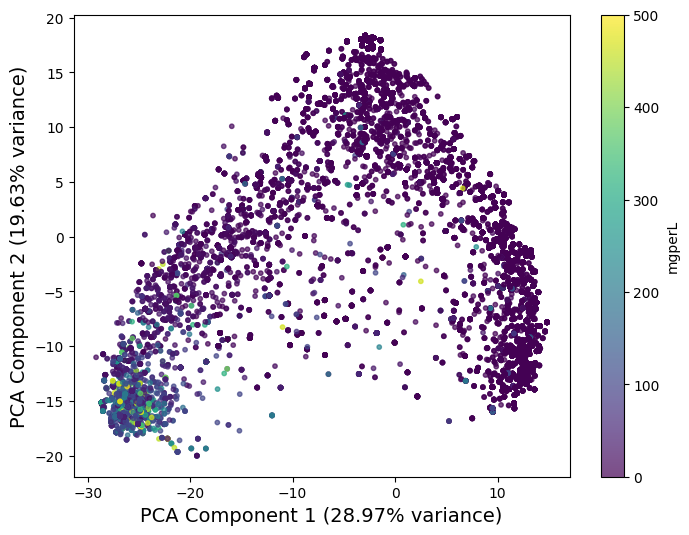

In [17]:
# 使用 PCA 对嵌入进行降维，同时获取主成分的解释方差百分比
def apply_pca(embeddings, n_components=2):
    pca = PCA(n_components=n_components)
    pca_result = pca.fit_transform(embeddings)
    explained_variance = pca.explained_variance_ratio_  # 获取每个主成分的解释方差
    return pca_result, explained_variance

# 可视化函数，同时显示解释方差百分比
def plot_pca_with_variance(pca_result, labels, explained_variance):
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(pca_result[:, 0], pca_result[:, 1], c=labels, cmap='viridis', alpha=0.7,s=10)
    plt.colorbar(scatter, label='mgperL')
    #plt.title(f'PCA of SMILES Embeddings with mgperL Heatmap\n'
    #          f'Explained Variance: PC1: {explained_variance[0]*100:.2f}%, PC2: {explained_variance[1]*100:.2f}%')
    plt.xlabel(f'PCA Component 1 ({explained_variance[0]*100:.2f}% variance)', fontsize=14)
    plt.ylabel(f'PCA Component 2 ({explained_variance[1]*100:.2f}% variance)', fontsize=14)
    plt.show()


mgperL = data['mgperL'].values
# 使用 PCA 降维，并获取解释方差
pca_result, explained_variance = apply_pca(smiles_embeddings, n_components=2)

# 绘制 PCA 图，并显示每个主成分的解释方差百分比
plot_pca_with_variance(pca_result, mgperL, explained_variance)

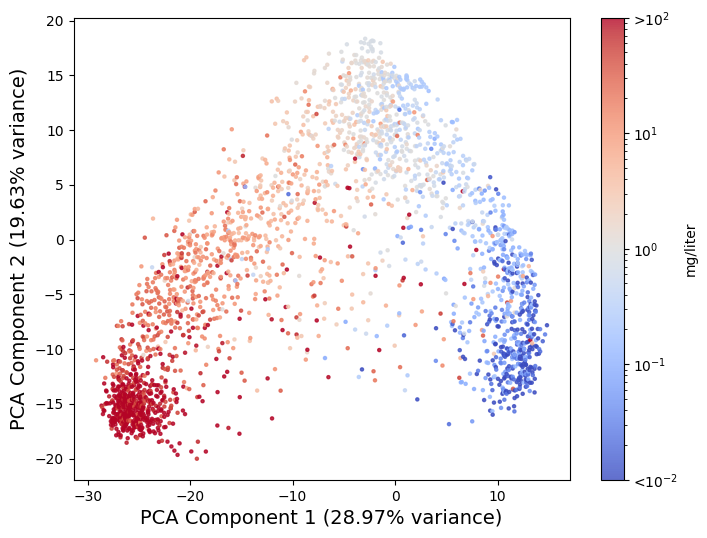

In [19]:
# 创建 DataFrame 用于处理重复值
pca_df = pd.DataFrame(pca_result, columns=['PC1', 'PC2'])
pca_df['mgperL'] = data['mgperL'].values

# 去重并计算相同 PCA 结果的中位数 mgperL
unique_pca_df = pca_df.groupby(['PC1', 'PC2'])['mgperL'].median().reset_index()
PCA_DF = unique_pca_df[['PC1', 'PC2']]


import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# 可视化函数，同时显示解释方差百分比
def plot_pca_with_variance(pca_result, labels, explained_variance):
    plt.figure(figsize=(8, 6))

    # 使用 LogNorm 创建对数色标
    scatter = plt.scatter(
        pca_result['PC1'], pca_result['PC2'], 
        c=labels, 
        cmap='coolwarm',  # 可更换成其他配色
        norm=LogNorm(vmin=0.01, vmax=100),  # 设置对数刻度，0.01和100为最深颜色
        alpha=0.8, s=5
    )

    # 添加颜色条并设置刻度
    cbar = plt.colorbar(scatter, label='mg/liter')
    cbar.set_ticks([0.01, 0.1, 1, 10, 100])  # 设置对数刻度的主要刻度
    cbar.set_ticklabels([r'<10$^{-2}$', r'10$^{-1}$', r'10$^{0}$', r'10$^{1}$', r'>10$^{2}$'])  # 自定义标签

    plt.xlabel(f'PCA Component 1 ({explained_variance[0]*100:.2f}% variance)', fontsize=14)
    plt.ylabel(f'PCA Component 2 ({explained_variance[1]*100:.2f}% variance)', fontsize=14)
    
    plt.show()
plot_pca_with_variance(PCA_DF, unique_pca_df['mgperL'], explained_variance)

In [20]:
np.save('./fish_EC10_smiles_embeddings.npy', smiles_embeddings)

In [ ]:
#val_r2 = r2_score(np.expm1(all_labels), np.expm1(all_preds))  # 还原 log1p 的值